   gender race/ethnicity parental level of education         lunch  \
0    male        group A                 high school      standard   
1  female        group D            some high school  free/reduced   
2    male        group E                some college  free/reduced   
3    male        group B                 high school      standard   
4    male        group E          associate's degree      standard   

  test preparation course  math score  reading score  writing score  
0               completed          67             67             63  
1                    none          40             59             55  
2                    none          59             60             50  
3                    none          77             78             68  
4               completed          78             73             68  
X_train: (800, 10)
X_test : (200, 10)

Logistic Regression Performance:

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Decision Tree Performance

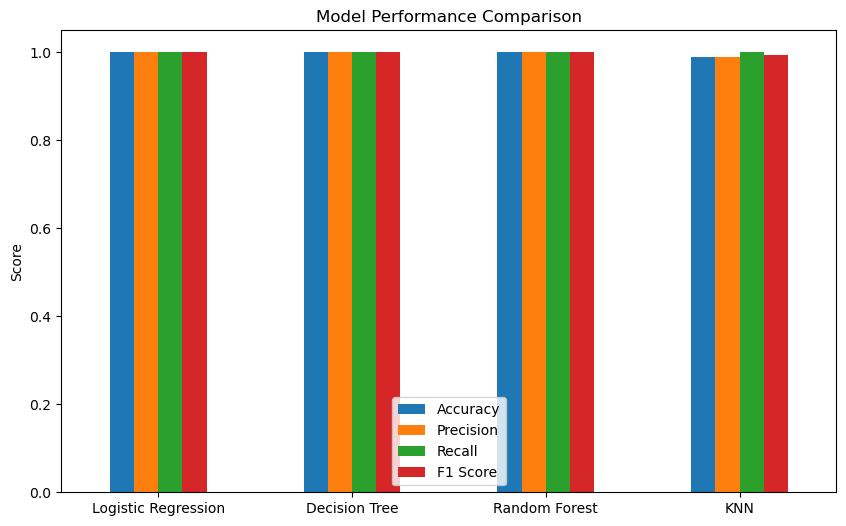


Best Model: Logistic Regression

FINAL CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00       194

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


CONFUSION MATRIX:

[[  6   0]
 [  0 194]]

ML Pipeline Completed Successfully!


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv(r"C:\Users\alha\Downloads\final program\exams.csv")

df.columns = df.columns.str.strip()

print(df.head())

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Total_Marks'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

df['Average_Marks'] = df['Total_Marks'] / 3

df['Pass'] = np.where(df['Average_Marks'] >= 40, 1, 0)

label_encoder = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

X = df.drop("Pass", axis=1)

y = df["Pass"]

label_encoder = LabelEncoder()

cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    X[col] = label_encoder.fit_transform(X[col].astype(str))

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

models = {
    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"\n{name} Performance:\n")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

results_df = pd.DataFrame(results).T

print("\nMODEL COMPARISON:\n")
print(results_df)

results_df.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

best_model_name = results_df['Accuracy'].idxmax()

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

final_pred = best_model.predict(X_test)

print("\nFINAL CLASSIFICATION REPORT:\n")

print(classification_report(y_test, final_pred))

print("\nCONFUSION MATRIX:\n")

print(confusion_matrix(y_test, final_pred))

if hasattr(best_model, 'feature_importances_'):

    importance = best_model.feature_importances_

    feature_names = X.columns

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFeature Importance:\n")
    print(importance_df)

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Features")

    plt.title("Feature Importance")

    plt.gca().invert_yaxis()

    plt.show()

print("\nML Pipeline Completed Successfully!")